# 韓国 KOSPI 週足 メディアン統計とモメンタム

In [19]:
import sys

path_up = ".."
if not path_up in sys.path:
    sys.path.append(path_up)

In [20]:
import datetime
import os

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import mplfinance as mpf
import numpy as np
import pandas as pd
import pingouin as pg
import seaborn as sns
import yfinance as yf
from scipy import stats

from funcs.technical import calc_robust_bollinger

In [21]:
code = "KS11"
symbol = "^%s" % code
yticker = yf.Ticker(symbol)

In [22]:
### 最新のデータが取得されていることを確認 ###
yticker.history(period="5d", interval="1d")

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-06-15 00:00:00+09:00,8526.120117,8603.480469,8450.240234,8545.980469,516600,0.0,0.0
2026-06-16 00:00:00+09:00,8696.549805,8753.820312,8540.410156,8726.599609,586300,0.0,0.0
2026-06-17 00:00:00+09:00,8622.129883,8872.179688,8605.660156,8864.240234,571200,0.0,0.0
2026-06-18 00:00:00+09:00,8884.919922,9106.070312,8867.339844,9063.839844,510900,0.0,0.0
2026-06-19 00:00:00+09:00,9288.889648,9385.589844,8831.719727,9052.419922,517200,0.0,0.0


In [23]:
# 週足で過去 5 年分のデータを取得
df0 = yticker.history(period="10y", interval="1wk")

# ローソク足のチャートには、そのうち過去 3 年分のみ使用する
dt_last = df0.index[len(df0) - 1]
tdelta_2y = datetime.timedelta(days=365 * 2)
df = df0[df0.index >= dt_last - tdelta_2y]

In [24]:
dt = df.tail(1).index[0]
year_str = f"{dt.year:04d}"
date_str = f"{dt.month:02d}{dt.day:02d}"
date_str

'0615'

## Moving Median

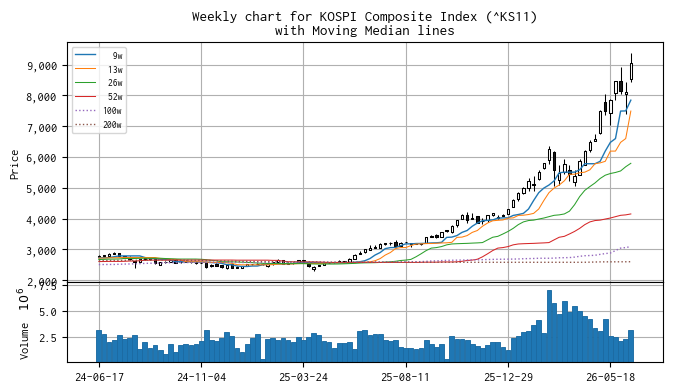

In [25]:
FONT_PATH = "../fonts/RictyDiminished-Regular.ttf"
fm.fontManager.addfont(FONT_PATH)

# FontPropertiesオブジェクト生成（名前の取得のため）
font_prop = fm.FontProperties(fname=FONT_PATH)
font_prop.get_name()

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.size"] = 9

fig = plt.figure(figsize=(6.8, 4))
ax = dict()
n = 2
gs = fig.add_gridspec(
    n, 1, wspace=0.0, hspace=0.0, height_ratios=[3 if i == 0 else 1 for i in range(n)]
)
for i, axis in enumerate(gs.subplots(sharex="col")):
    ax[i] = axis
    ax[i].grid()

mm09 = df0["Close"].rolling(9).median()
mm13 = df0["Close"].rolling(13).median()
mm26 = df0["Close"].rolling(26).median()
mm52 = df0["Close"].rolling(52).median()
mm100 = df0["Close"].rolling(100).median()
mm200 = df0["Close"].rolling(200).median()

apds = [
    mpf.make_addplot(mm09[df.index], width=1, label="  9w", ax=ax[0]),
    mpf.make_addplot(mm13[df.index], width=0.75, label=" 13w", ax=ax[0]),
    mpf.make_addplot(mm26[df.index], width=0.75, label=" 26w", ax=ax[0]),
    mpf.make_addplot(mm52[df.index], width=0.75, label=" 52w", ax=ax[0]),
    mpf.make_addplot(
        mm100[df.index],
        width=1,
        linestyle="dotted",
        label="100w",
        ax=ax[0],
    ),
    mpf.make_addplot(
        mm200[df.index],
        width=1,
        linestyle="dotted",
        label="200w",
        ax=ax[0],
    ),
]

mpf.plot(
    df,
    type="candle",
    style="default",
    volume=ax[1],
    datetime_format="%y-%m-%d",
    addplot=apds,
    xrotation=0,
    update_width_config=dict(candle_linewidth=0.75),
    ax=ax[0],
)

ax[0].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
ax[0].set_title(
    f"Weekly chart for {yticker.info["longName"]} ({symbol})\nwith Moving Median lines"
)
ax[0].legend(loc="upper left", fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(year_str, f"{date_str}_report_weekly_chart_median_{code}.png"))
plt.show()

In [26]:
df.tail(2)

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-06-08 00:00:00+09:00,8048.089844,8434.400391,7394.459961,8123.620117,2333700,0.0,0.0
2026-06-15 00:00:00+09:00,8526.120117,9385.589844,8450.240234,9052.419922,3219448,0.0,0.0


In [27]:
df.tail(2)["Close"]

Date
2026-06-08 00:00:00+09:00    8123.620117
2026-06-15 00:00:00+09:00    9052.419922
Name: Close, dtype: float64

In [28]:
df.tail(2)["Close"].diff()

Date
2026-06-08 00:00:00+09:00           NaN
2026-06-15 00:00:00+09:00    928.799805
Name: Close, dtype: float64

In [29]:
df["Close"].rolling(9).median().tail(10)

Date
2026-04-13 00:00:00+09:00    5781.200195
2026-04-20 00:00:00+09:00    5781.200195
2026-04-27 00:00:00+09:00    5781.200195
2026-05-04 00:00:00+09:00    5858.870117
2026-05-11 00:00:00+09:00    6191.919922
2026-05-18 00:00:00+09:00    6475.629883
2026-05-25 00:00:00+09:00    6598.870117
2026-06-01 00:00:00+09:00    7493.180176
2026-06-08 00:00:00+09:00    7498.000000
2026-06-15 00:00:00+09:00    7847.709961
Name: Close, dtype: float64

In [30]:
df["Close"].rolling(13).median().tail(10)

Date
2026-04-13 00:00:00+09:00    5507.009766
2026-04-20 00:00:00+09:00    5584.870117
2026-04-27 00:00:00+09:00    5781.200195
2026-05-04 00:00:00+09:00    5808.529785
2026-05-11 00:00:00+09:00    5858.870117
2026-05-18 00:00:00+09:00    6191.919922
2026-05-25 00:00:00+09:00    6191.919922
2026-06-01 00:00:00+09:00    6475.629883
2026-06-08 00:00:00+09:00    6598.870117
2026-06-15 00:00:00+09:00    7493.180176
Name: Close, dtype: float64

In [31]:
df["Close"].rolling(26).median().tail(5)

Date
2026-05-18 00:00:00+09:00    5463.055176
2026-05-25 00:00:00+09:00    5497.125000
2026-06-01 00:00:00+09:00    5545.939941
2026-06-08 00:00:00+09:00    5683.035156
2026-06-15 00:00:00+09:00    5794.864990
Name: Close, dtype: float64

In [32]:
df["Close"].rolling(52).median().tail(5)

Date
2026-05-18 00:00:00+09:00    4016.060059
2026-05-25 00:00:00+09:00    4060.299927
2026-06-01 00:00:00+09:00    4103.774902
2026-06-08 00:00:00+09:00    4118.590088
2026-06-15 00:00:00+09:00    4148.420166
Name: Close, dtype: float64

In [33]:
df0["Close"].rolling(100).median().tail(5)

Date
2026-05-18 00:00:00+09:00    2878.425049
2026-05-25 00:00:00+09:00    2958.230103
2026-06-01 00:00:00+09:00    3038.060059
2026-06-08 00:00:00+09:00    3055.109985
2026-06-15 00:00:00+09:00    3087.674927
Name: Close, dtype: float64

In [34]:
df0["Close"].rolling(200).median().tail(5)

Date
2026-05-18 00:00:00+09:00    2591.560059
2026-05-25 00:00:00+09:00    2591.975098
2026-06-01 00:00:00+09:00    2592.730103
2026-06-08 00:00:00+09:00    2593.595093
2026-06-15 00:00:00+09:00    2595.364990
Name: Close, dtype: float64

## Robust Bollinger bands

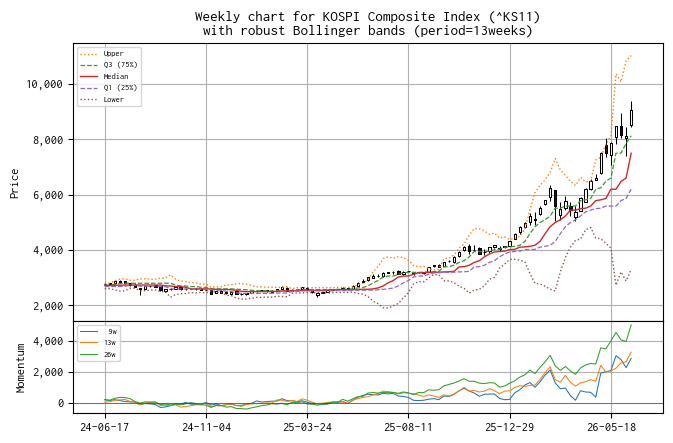

In [35]:
FONT_PATH = "../fonts/RictyDiminished-Regular.ttf"
fm.fontManager.addfont(FONT_PATH)

# FontPropertiesオブジェクト生成（名前の取得のため）
font_prop = fm.FontProperties(fname=FONT_PATH)
font_prop.get_name()

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.size"] = 9

# fig, ax = plt.subplots(figsize=(6, 3.5))
fig = plt.figure(figsize=(6.8, 4.5))
ax = dict()
n = 2
gs = fig.add_gridspec(
    n, 1, wspace=0.0, hspace=0.0, height_ratios=[3 if i == 0 else 1 for i in range(n)]
)
for i, axis in enumerate(gs.subplots(sharex="col")):
    ax[i] = axis
    ax[i].grid()

# Bollinger bands
period = 13
mv_median = df0["Close"].rolling(period).median()
mv_q1 = df0["Close"].rolling(period).quantile(0.25)
mv_q3 = df0["Close"].rolling(period).quantile(0.75)
mv_iqr = mv_q3 - mv_q1
mv_lower = mv_q1 - mv_iqr * 1.5
mv_upper = mv_q3 + mv_iqr * 1.5

mom09 = df0["Close"] - df0["Close"].shift(9, axis=0)
mom13 = df0["Close"] - df0["Close"].shift(13, axis=0)
mom26 = df0["Close"] - df0["Close"].shift(26, axis=0)

apds = [
    mpf.make_addplot(
        mv_upper[df.index],
        width=1,
        color="C1",
        linestyle="dotted",
        label="Upper",
        ax=ax[0],
    ),
    mpf.make_addplot(
        mv_q3[df.index],
        width=0.9,
        color="C2",
        linestyle="dashed",
        label="Q3 (75%)",
        ax=ax[0],
    ),
    mpf.make_addplot(
        mv_median[df.index],
        width=1,
        color="C3",
        linestyle="solid",
        label="Median",
        ax=ax[0],
    ),
    mpf.make_addplot(
        mv_q1[df.index],
        width=0.9,
        color="C4",
        linestyle="dashed",
        label="Q1 (25%)",
        ax=ax[0],
    ),
    mpf.make_addplot(
        mv_lower[df.index],
        width=1,
        color="C5",
        linestyle="dotted",
        label="Lower",
        ax=ax[0],
    ),
    mpf.make_addplot(
        mom09[df.index],
        width=0.75,
        linestyle="solid",
        label=" 9w",
        ax=ax[1],
    ),
    mpf.make_addplot(
        mom13[df.index],
        width=0.75,
        linestyle="solid",
        label="13w",
        ax=ax[1],
    ),
    mpf.make_addplot(
        mom26[df.index],
        width=0.75,
        linestyle="solid",
        label="26w",
        ax=ax[1],
    ),
]

mpf.plot(
    df,
    type="candle",
    style="default",
    addplot=apds,
    datetime_format="%y-%m-%d",
    xrotation=0,
    update_width_config=dict(candle_linewidth=0.75),
    ax=ax[0],
)

# ax.grid()
ax[0].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
ax[0].legend(loc="best", fontsize=6)

ax[1].axhline(y=0, color="black", alpha=0.5, linewidth=0.5)
ax[1].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
ax[1].set_ylabel("Momentum")
ax[1].legend(loc="best", fontsize=6)

try:
    ax[0].set_title(
        f"Weekly chart for {yticker.info['longName']} ({symbol})\nwith robust Bollinger bands (period={period}weeks)"
    )
except KeyError:
    ax[0].set_title(
        f"Weekly chart for {symbol}\nwith robust Bollinger bands (period={period}weeks)"
    )

plt.tight_layout()
plt.savefig(
    os.path.join(
        year_str, f"{date_str}_report_weekly_chart_bollinger_robust_{code}.png"
    )
)
plt.show()

## ヒストグラムと Q-Q プロット

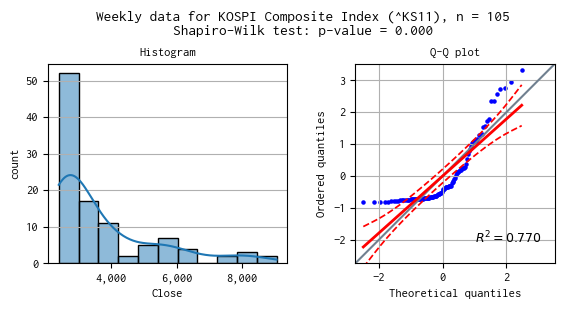

In [36]:
plt.rcParams["font.size"] = 9
fig, axes = plt.subplots(1, 2, figsize=(6.8, 3))

sns.histplot(df["Close"], kde=True, ax=axes[0])

# ヒストグラム
axes[0].set_xlabel("Close")
axes[0].set_ylabel("count")
axes[0].xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
axes[0].grid(axis="y")
axes[0].set_title("Histogram", fontsize=9)

# Q-Q プロット
pg.qqplot(df["Close"], s=5, ax=axes[1])
axes[1].set_title("Q-Q plot", fontsize=9)
axes[1].grid()

shapiro_test = stats.shapiro(df["Close"])
title_str = (
    f"Weekly data for {yticker.info["longName"]} ({symbol}), n = {len(df)}\n"
    f"Shapiro-Wilk test: p-value = {shapiro_test.pvalue:.3f}"
)
plt.suptitle(
    title_str,
    fontsize=11,
)
plt.subplots_adjust(top=0.80, bottom=0.135, wspace=0.2)
plt.savefig(
    os.path.join(year_str, f"{date_str}_report_weekly_histogram_qqplot_{code}.png")
)
plt.show()